In [1]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import os
# import numpy as np

# # --- Configuration ---
# ports_to_process = [7, 6, 11, 15, 16, 22, 29, 36]
# num_levels = 10
# input_directory = "processed_csvs"
# plot_directory = "Variable_Isolation_Plots"
# relations_file = "relations.csv"

# # Create directories
# os.makedirs(plot_directory, exist_ok=True)

# # Prepare list to store numerical results
# relations_data = []

# print(f"Starting analysis. Saving plots to '{plot_directory}' and summary to '{relations_file}'...")

# for port in ports_to_process:
    
#     print(f"Processing Port {port}...")
    
#     # Create sub-folder for plots
#     port_plot_dir = os.path.join(plot_directory, f"Port_{port}")
#     os.makedirs(port_plot_dir, exist_ok=True)
    
#     for level in range(1, num_levels + 1):
#         filename = f"{input_directory}/processed_data_port_{port}_level_{level}.csv"
        
#         if not os.path.exists(filename):
#             continue
            
#         try:
#             df = pd.read_csv(filename)
#             if df.empty: continue
#         except:
#             continue

#         # --- 1. Filter for Constant Tdry ---
#         # We use the median tdry +/- 0.5 hours
#         median_tdry = df['tdry'].median()
#         tolerance = 0.5
        
#         subset = df[ (df['tdry'] >= median_tdry - tolerance) & 
#                      (df['tdry'] <= median_tdry + tolerance) ]
        
#         # Skip if not enough data (less than 10 points makes plotting useless)
#         if len(subset) < 10:
#             continue

#         # --- 2. Calculate Dominance (Numerical Analysis) ---
#         # We calculate correlation of CZD with other vars within this subset
#         corr = subset[['CZD', 'twet', 'J_avg', 'TEQ_avg']].corr()['CZD'].abs()
        
#         # Find the variable with the highest correlation (excluding CZD itself)
#         corr = corr.fillna(0)
#         # Drop CZD so it doesn't pick itself
#         candidates = corr.drop('CZD', errors='ignore')
        
#         if not candidates.empty:
#             best_var = candidates.idxmax()
#             best_score = candidates.max()
#         else:
#             best_var = "None"
#             best_score = 0
        
#         relations_data.append({
#             'Port': port,
#             'Level': level,
#             'Constant_Tdry_Value': round(median_tdry, 2),
#             'Total_Rows': len(df),       # <--- NEW COLUMN: Total rows in file
#             'Subset_Size': len(subset),  # Rows used for this analysis
#             'Corr_twet': round(corr.get('twet', 0), 3),
#             'Corr_J_avg': round(corr.get('J_avg', 0), 3),
#             'Corr_TEQ_avg': round(corr.get('TEQ_avg', 0), 3),
#             'Dominant_Factor': best_var,
#             'Dominance_Score': round(best_score, 3)
#         })

#         # --- 3. Generate & Save Plot ---
#         fig, axes = plt.subplots(1, 3, figsize=(18, 6))
#         fig.suptitle(f'Port {port}, Level {level}: Variation at constant tdry (~{median_tdry:.1f} hrs)\nDominant Factor: {best_var} (Corr: {best_score:.2f})', fontsize=14)

#         # Plot 1: CZD vs twet
#         axes[0].scatter(subset['twet'], subset['CZD'], color='blue', alpha=0.6)
#         axes[0].set_xlabel('twet (hours)')
#         axes[0].set_ylabel('CZD')
#         axes[0].set_title(f'twet (Corr: {corr.get("twet",0):.2f})')
#         axes[0].grid(True, linestyle='--')

#         # Plot 2: CZD vs J_avg
#         axes[1].scatter(subset['J_avg'], subset['CZD'], color='green', alpha=0.6)
#         axes[1].set_xlabel('J_avg (Flux)')
#         axes[1].set_ylabel('CZD')
#         axes[1].set_title(f'J_avg (Corr: {corr.get("J_avg",0):.2f})')
#         axes[1].grid(True, linestyle='--')
#         axes[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))

#         # Plot 3: CZD vs TEQ_avg
#         axes[2].scatter(subset['TEQ_avg'], subset['CZD'], color='red', alpha=0.6)
#         axes[2].set_xlabel('TEQ_avg (Moisture)')
#         axes[2].set_ylabel('CZD')
#         axes[2].set_title(f'TEQ_avg (Corr: {corr.get("TEQ_avg",0):.2f})')
#         axes[2].grid(True, linestyle='--')

#         plt.tight_layout()
        
#         plot_filename = f"{port_plot_dir}/isolation_plot_port_{port}_level_{level}.png"
#         plt.savefig(plot_filename)
#         plt.close(fig) # Close to free up memory

# # --- 4. Save Summary File ---
# results_df = pd.DataFrame(relations_data)
# results_df.to_csv(relations_file, index=False)

# print("\n" + "="*40)
# print(f"DONE!")
# print(f"1. Summary table saved to: '{relations_file}'")
# print(f"2. Plots saved in folder:  '{plot_directory}'")
# print("="*40)
# print("\nSample of relations found:")
# print(results_df.head())


import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# --- Configuration ---
ports_to_process = [7, 6, 11, 15, 16, 22, 29, 36]
num_levels = 10
input_directory = "processed_csvs"
plot_directory = "Variable_Isolation_Plots"
relations_file = "relations.csv"

# --- Visual Preferences ---
# Set global font to Times New Roman (or Arial if preferred)
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
# If you prefer Arial, uncomment the next two lines and comment out the two above:
# plt.rcParams["font.family"] = "sans-serif"
# plt.rcParams["font.sans-serif"] = ["Arial"]

# Increase font sizes for better visibility
main_title_fs = 24  # Main super title
title_fs = 20       # Subplot titles
label_fs = 18       # Axis labels
tick_fs = 16        # Tick numbers

# Create directories
os.makedirs(plot_directory, exist_ok=True)

# Prepare list to store numerical results
relations_data = []

print(f"Starting analysis. Saving plots to '{plot_directory}' and summary to '{relations_file}'...")

for port in ports_to_process:
    
    print(f"Processing Port {port}...")
    
    # Create sub-folder for plots
    port_plot_dir = os.path.join(plot_directory, f"Port_{port}")
    os.makedirs(port_plot_dir, exist_ok=True)
    
    for level in range(1, num_levels + 1):
        filename = f"{input_directory}/processed_data_port_{port}_level_{level}.csv"
        
        if not os.path.exists(filename):
            continue
            
        try:
            df = pd.read_csv(filename)
            if df.empty: continue
        except:
            continue

        # --- 1. Filter for Constant Tdry ---
        median_tdry = df['tdry'].median()
        tolerance = 0.5
        
        subset = df[(df['tdry'] >= median_tdry - tolerance) & 
                    (df['tdry'] <= median_tdry + tolerance)]
        
        if len(subset) < 10:
            continue

        # --- 2. Calculate Dominance ---
        corr = subset[['CZD', 'twet', 'J_avg', 'TEQ_avg']].corr()['CZD'].abs()
        corr = corr.fillna(0)
        candidates = corr.drop('CZD', errors='ignore')
        
        if not candidates.empty:
            best_var = candidates.idxmax()
            best_score = candidates.max()
        else:
            best_var = "None"
            best_score = 0
        
        relations_data.append({
            'Port': port,
            'Level': level,
            'Constant_Tdry_Value': round(median_tdry, 2),
            'Total_Rows': len(df),
            'Subset_Size': len(subset),
            'Corr_twet': round(corr.get('twet', 0), 3),
            'Corr_J_avg': round(corr.get('J_avg', 0), 3),
            'Corr_TEQ_avg': round(corr.get('TEQ_avg', 0), 3),
            'Dominant_Factor': best_var,
            'Dominance_Score': round(best_score, 3)
        })

        # --- 3. Generate Plot ---
        fig, axes = plt.subplots(1, 3, figsize=(20, 7))

        # Format the variable name for the title to look like math (subscript)
        # Replaces J_avg with J_{avg} for the title display
        display_best_var = best_var.replace('_avg', '_{avg}')
        if "avg" in display_best_var:
            display_best_var = f"${display_best_var}$"

        fig.suptitle(
            f'Port {port}, Level {level}: Variation at constant $t_{{dry}}$ (~{median_tdry:.1f} hrs)\n'
            f'Dominant Factor: {display_best_var} (Corr: {best_score:.2f})',
            fontsize=main_title_fs, fontweight='bold'
        )

        # Plot 1: CZD vs twet
        axes[0].scatter(subset['twet'], subset['CZD'], color='blue', alpha=0.6)
        axes[0].set_xlabel(r'$t_{wet}$ (hours)', fontsize=label_fs)
        axes[0].set_ylabel('CZD', fontsize=label_fs)
        axes[0].set_title(f'$t_{{wet}}$ (Corr: {corr.get("twet",0):.2f})', fontsize=title_fs)
        axes[0].tick_params(axis='both', labelsize=tick_fs)
        axes[0].grid(True, linestyle='--')

        # Plot 2: CZD vs J_avg
        axes[1].scatter(subset['J_avg'], subset['CZD'], color='green', alpha=0.6)
        axes[1].set_xlabel(r'$J_{avg}$ (Flux)', fontsize=label_fs)
        axes[1].set_ylabel('CZD', fontsize=label_fs)
        axes[1].set_title(f'$J_{{avg}}$ (Corr: {corr.get("J_avg",0):.2f})', fontsize=title_fs)
        axes[1].tick_params(axis='both', labelsize=tick_fs)
        axes[1].grid(True, linestyle='--')
        
        # Format scientific notation for Flux axis
        axes[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
        # Ensure the scientific notation offset text (e.g. 1e-6) is also large enough
        axes[1].xaxis.get_offset_text().set_fontsize(tick_fs)

        # Plot 3: CZD vs TEQ_avg
        axes[2].scatter(subset['TEQ_avg'], subset['CZD'], color='red', alpha=0.6)
        axes[2].set_xlabel(r'$TEQ_{avg}$ (Moisture)', fontsize=label_fs)
        axes[2].set_ylabel('CZD', fontsize=label_fs)
        axes[2].set_title(f'$TEQ_{{avg}}$ (Corr: {corr.get("TEQ_avg",0):.2f})', fontsize=title_fs)
        axes[2].tick_params(axis='both', labelsize=tick_fs)
        axes[2].grid(True, linestyle='--')

        plt.tight_layout()
        plt.subplots_adjust(top=0.85) # Adjust top to make room for the larger Main Title
        plt.savefig(f"{port_plot_dir}/isolation_plot_port_{port}_level_{level}.png")
        plt.close(fig)

# Save Summary File
results_df = pd.DataFrame(relations_data)
results_df.to_csv(relations_file, index=False)

print("\nDONE!")

Starting analysis. Saving plots to 'Variable_Isolation_Plots' and summary to 'relations.csv'...
Processing Port 7...
Processing Port 6...
Processing Port 11...
Processing Port 15...
Processing Port 16...
Processing Port 22...
Processing Port 29...
Processing Port 36...

DONE!


In [9]:
import pandas as pd
import os

# --- Configuration ---
csv_file = "relations.csv"

if not os.path.exists(csv_file):
    print(f"Error: '{csv_file}' not found.")
    exit()

# 1. Load the CSV
print(f"Loading '{csv_file}'...")
df = pd.read_csv(csv_file)
print(f"Original rows: {len(df)}")

# ==========================================
# --- EDITING LOGIC ---
# ==========================================

# --- NEW: Add Port Name Column ---
port_names = {
    7: 'Cochin',
    6: 'Chennai',
    11: 'GardenReach',
    15: 'JNPT',
    16: 'Kakinada',
    22: 'Machilipatnam',
    29: 'Paradeep',
    36: 'Visakhapatnam'
}

# Use map to create the new column
df['Port_Name'] = df['Port'].map(port_names)

# Reorder columns to put Port_Name next to Port
cols = list(df.columns)
if 'Port_Name' in cols:
    cols.insert(1, cols.pop(cols.index('Port_Name'))) # Move Port_Name to 2nd position
    df = df[cols]

# Example Edit 1: Filter out rows with small subsets (e.g., < 20 points)
# df_clean = df[df['Subset_Size'] >= 20].copy()
# print(f"Rows after filtering size < 20: {len(df_clean)}")
df_clean = df.copy()

# --- REMOVED CONFIDENCE COLUMN LOGIC ---
# We are NOT adding the 'Confidence' column as requested.
# ---------------------------------------

# --- REMOVED RENAMING LOGIC ---
# We are keeping the original variable names (twet, J_avg, TEQ_avg).
# ------------------------------

# ==========================================
# --- END EDITING LOGIC ---
# ==========================================

# 3. Save back to CSV
output_file = "relations_with_names.csv" 
df_clean.to_csv(output_file, index=False)

print(f"\nSuccess! Edited data with Port Names saved to '{output_file}'.")
print("First 5 rows of edited data:")
print(df_clean.head())

Loading 'relations.csv'...
Original rows: 79

Success! Edited data with Port Names saved to 'relations_with_names.csv'.
First 5 rows of edited data:
   Port Port_Name  Level  Constant_Tdry_Value  Total_Rows  Subset_Size  \
0     7    Cochin      1                 0.33          80           80   
1     7    Cochin      2                 0.50        1375         1375   
2     7    Cochin      3                 1.33        7143         4245   
3     7    Cochin      4                 3.20       13413         3005   
4     7    Cochin      5                 4.78       32284         5744   

   Corr_twet  Corr_J_avg  Corr_TEQ_avg Dominant_Factor  Dominance_Score  
0      0.170       0.254         0.318         TEQ_avg            0.318  
1      0.166       0.294         0.200           J_avg            0.294  
2      0.055       0.550         0.405           J_avg            0.550  
3      0.010       0.087         0.042           J_avg            0.087  
4      0.024       0.274         0.1

In [11]:
import pandas as pd
import os

# --- Configuration ---
input_directory = "processed_csvs"
output_directory = "tdry_frequency_analysis"

# Create the output directory if it doesn't exist
os.makedirs(output_directory, exist_ok=True)

print(f"Starting analysis. Reading from '{input_directory}'...")
print(f"Saving frequency files to '{output_directory}'...")

# Get all CSV files in the processed folder
all_files = [f for f in os.listdir(input_directory) if f.endswith(".csv")]

count_files_created = 0

for filename in all_files:
    input_path = os.path.join(input_directory, filename)
    
    try:
        # Load the data
        df = pd.read_csv(input_path)
        
        if df.empty:
            continue
            
        # --- THE ANALYSIS LOGIC ---
        # 1. Round tdry to 1 decimal place to group similar values
        #    (e.g., 1.0001 -> 1.0)
        df['tdry_rounded'] = df['tdry'].round(1)
        
        # 2. Count unique values based on the rounded column
        tdry_counts = df['tdry_rounded'].value_counts().reset_index()
        
        # Rename columns for clarity
        tdry_counts.columns = ['tdry_value', 'count']
        
        # Optional: Sort by value so it's easier to read (e.g., 1.0, 1.5, 2.0...)
        tdry_counts = tdry_counts.sort_values(by='tdry_value')
        
        # --- SAVE NEW FILE ---
        # Create a new filename based on the original
        # e.g., "processed_data_port_7_level_1.csv" -> "tdry_counts_port_7_level_1.csv"
        new_filename = filename.replace("processed_data_", "tdry_counts_")
        output_path = os.path.join(output_directory, new_filename)
        
        tdry_counts.to_csv(output_path, index=False)
        count_files_created += 1
        
    except Exception as e:
        print(f"Error processing {filename}: {e}")

print("\n" + "="*40)
print(f"DONE! Created {count_files_created} frequency files.")
print(f"Check the folder: '{output_directory}'")
print("="*40)

Starting analysis. Reading from 'processed_csvs'...
Saving frequency files to 'tdry_frequency_analysis'...

DONE! Created 80 frequency files.
Check the folder: 'tdry_frequency_analysis'


Loaded 9327 rows for Port 6, Level 8
Rows after dropping NaNs: 9327

Auto-chosen tdry (median) = 20.817 hours

Filtering for tdry ≈ 20.817 ± 0.5 hours
Number of points in this band: 414

--- Correlation of CZD with each parameter (within chosen tdry band) ---
twet       0.749084
J_avg      0.024544
TEQ_avg   -0.015682
Name: CZD, dtype: float64

--- Standardized Linear Regression Coefficients ---
Model: CZD = a*twet_std + b*J_avg_std + c*TEQ_avg_std + intercept
twet       1.933347
J_avg      0.040148
TEQ_avg   -0.007709
dtype: float64

Dominance summary for tdry ≈ 20.817 ± 0.5 hours
---------------------------------------------------
By |correlation|, dominant parameter = twet (|r| = 0.749)
By |regression coefficient|, dominant parameter = twet (|β| = 1.933)

✅ Both methods agree: CZD variation at this tdry is mainly driven by **twet**.

Saved diagnostic plot to: tdry_band_dominance_port_6_level_8.png


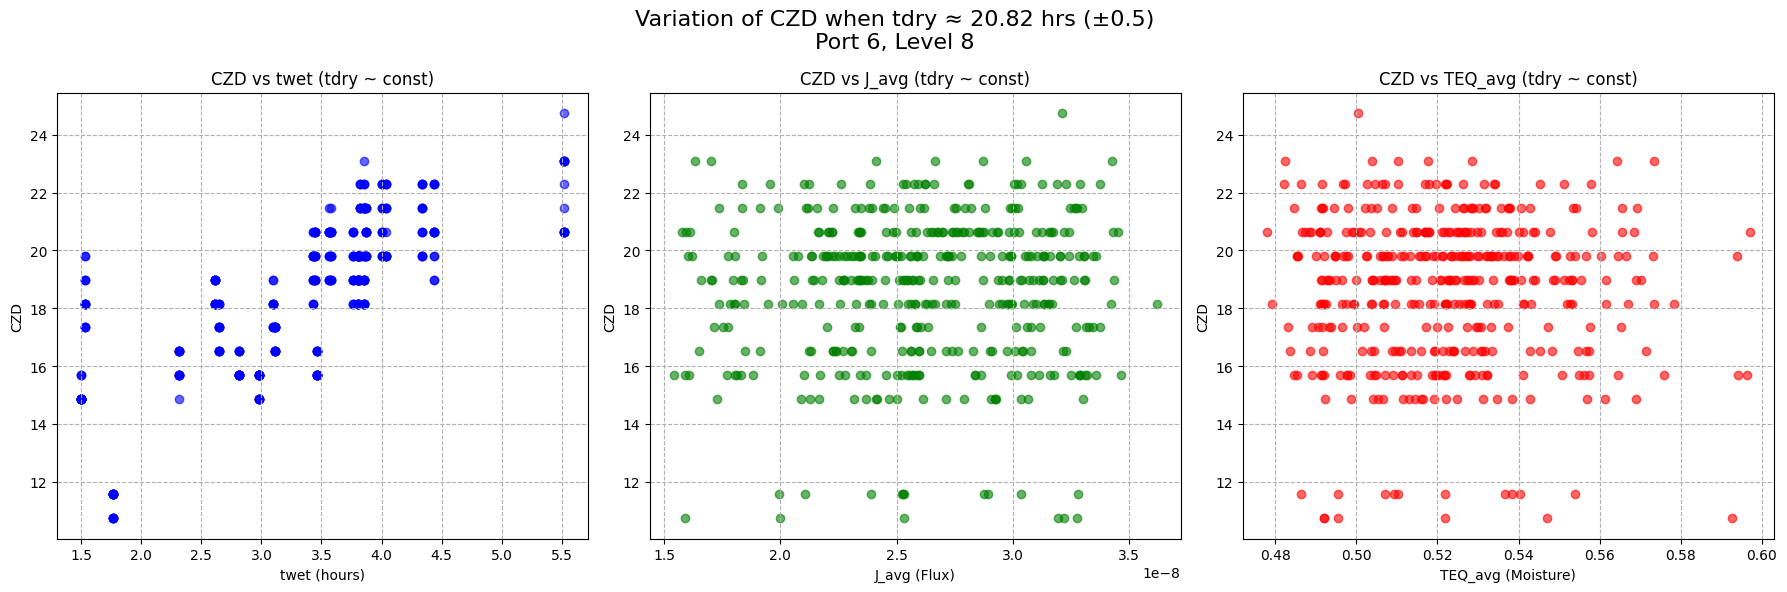

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# ============================
# 1. INPUT: choose port/level
# ============================
try:
    target_port = int(input("Enter Port Number (e.g., 6): "))
    target_level = int(input("Enter Level Number (1–10): "))
except ValueError:
    print("Invalid input. Please enter integers only.")
    raise SystemExit

input_file = f"processed_csvs/processed_data_port_{target_port}_level_{target_level}.csv"

if not os.path.exists(input_file):
    print(f"File not found: {input_file}")
    raise SystemExit

df = pd.read_csv(input_file)
print(f"Loaded {len(df)} rows for Port {target_port}, Level {target_level}")

required_cols = ["twet", "tdry", "J_avg", "TEQ_avg", "CZD"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in data!")

df = df.dropna(subset=required_cols).copy()
print("Rows after dropping NaNs:", len(df))

# =============================================
# 2. CHOOSE WHICH tdry TO HOLD APPROX CONSTANT
# =============================================

# Option A: automatically use median tdry
auto_tdry = df["tdry"].median()
print(f"\nAuto-chosen tdry (median) = {auto_tdry:.3f} hours")

use_auto = input("Use median tdry? (y/n): ").strip().lower()

if use_auto == "y":
    target_tdry = auto_tdry
else:
    # Option B: you enter a specific tdry
    try:
        target_tdry = float(input("Enter specific tdry value to analyze: "))
    except ValueError:
        print("Invalid tdry, falling back to median.")
        target_tdry = auto_tdry

# tolerance band around tdry (so we have enough points)
tolerance = float(input("Enter tolerance around tdry (e.g., 0.5 hours): ") or 0.5)

# ====================================
# 3. FILTER: keep rows with tdry ≈ const
# ====================================
subset = df[
    (df["tdry"] >= target_tdry - tolerance) &
    (df["tdry"] <= target_tdry + tolerance)
].copy()

print(f"\nFiltering for tdry ≈ {target_tdry:.3f} ± {tolerance} hours")
print("Number of points in this band:", len(subset))

if len(subset) < 20:
    print("⚠ Very few points in this range. Results may be noisy.")
    if len(subset) < 5:
        print("Too few points (<5). Consider increasing tolerance.")
        raise SystemExit

# ====================================
# 4. CORRELATION ANALYSIS (within this tdry band)
# ====================================
corr_mat = subset[["twet", "J_avg", "TEQ_avg", "CZD"]].corr()
corr_with_czd = corr_mat["CZD"].drop("CZD")  # only predictors

print("\n--- Correlation of CZD with each parameter (within chosen tdry band) ---")
print(corr_with_czd.sort_values(ascending=False))

# absolute correlation to judge strength (ignore sign)
abs_corr = corr_with_czd.abs()
dominant_corr_param = abs_corr.idxmax()

# ====================================
# 5. STANDARDIZED LINEAR REGRESSION
#    CZD ~ twet + J_avg + TEQ_avg
# ====================================
X = subset[["twet", "J_avg", "TEQ_avg"]].values
y = subset["CZD"].values

# Standardize predictors so coefficients are comparable
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

reg = LinearRegression()
reg.fit(X_std, y)
coef_vals = reg.coef_

coef_series = pd.Series(coef_vals, index=["twet", "J_avg", "TEQ_avg"])

print("\n--- Standardized Linear Regression Coefficients ---")
print("Model: CZD = a*twet_std + b*J_avg_std + c*TEQ_avg_std + intercept")
print(coef_series.sort_values(ascending=False))

abs_coef = coef_series.abs()
dominant_reg_param = abs_coef.idxmax()

# ====================================
# 6. FINAL ANSWER: which parameter dominates?
# ====================================
print("\n===================================================")
print("Dominance summary for tdry ≈ "
      f"{target_tdry:.3f} ± {tolerance} hours")
print("---------------------------------------------------")
print(f"By |correlation|, dominant parameter = {dominant_corr_param} "
      f"(|r| = {abs_corr[dominant_corr_param]:.3f})")
print(f"By |regression coefficient|, dominant parameter = {dominant_reg_param} "
      f"(|β| = {abs_coef[dominant_reg_param]:.3f})")

if dominant_corr_param == dominant_reg_param:
    print(f"\n✅ Both methods agree: CZD variation at this tdry is mainly driven by **{dominant_corr_param}**.")
else:
    print("\n⚠ Correlation and regression give different dominant parameters.")
    print("   Inspect plots below to interpret physically.")

# ====================================
# 7. (OPTIONAL) PLOTS TO VISUALIZE
# ====================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f"Variation of CZD when tdry ≈ {target_tdry:.2f} hrs "
    f"(±{tolerance})\nPort {target_port}, Level {target_level}",
    fontsize=16
)

axes[0].scatter(subset["twet"], subset["CZD"], color="blue", alpha=0.6)
axes[0].set_xlabel("twet (hours)")
axes[0].set_ylabel("CZD")
axes[0].set_title("CZD vs twet (tdry ~ const)")
axes[0].grid(True, linestyle="--")

axes[1].scatter(subset["J_avg"], subset["CZD"], color="green", alpha=0.6)
axes[1].set_xlabel("J_avg (Flux)")
axes[1].set_ylabel("CZD")
axes[1].set_title("CZD vs J_avg (tdry ~ const)")
axes[1].grid(True, linestyle="--")
axes[1].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

axes[2].scatter(subset["TEQ_avg"], subset["CZD"], color="red", alpha=0.6)
axes[2].set_xlabel("TEQ_avg (Moisture)")
axes[2].set_ylabel("CZD")
axes[2].set_title("CZD vs TEQ_avg (tdry ~ const)")
axes[2].grid(True, linestyle="--")

plt.tight_layout()
out_name = f"tdry_band_dominance_port_{target_port}_level_{target_level}.png"
plt.savefig(out_name, dpi=200)
print(f"\nSaved diagnostic plot to: {out_name}")
plt.show()


Loading S5 Twd J TEQ IDMT log(j).xlsx for Analysis...
Analyzing 71017 rows of clean data...


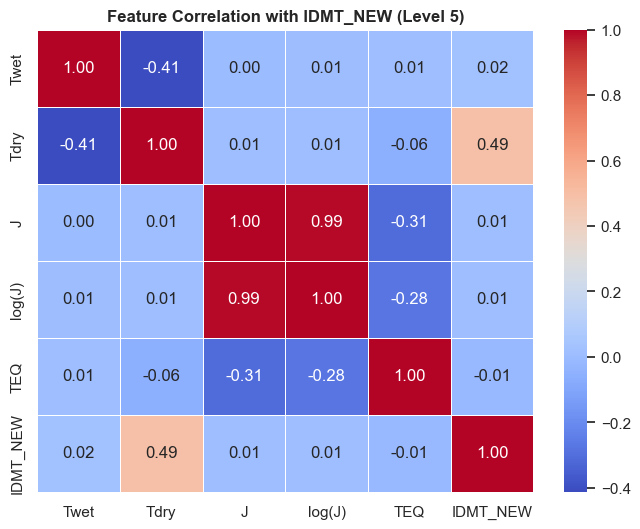

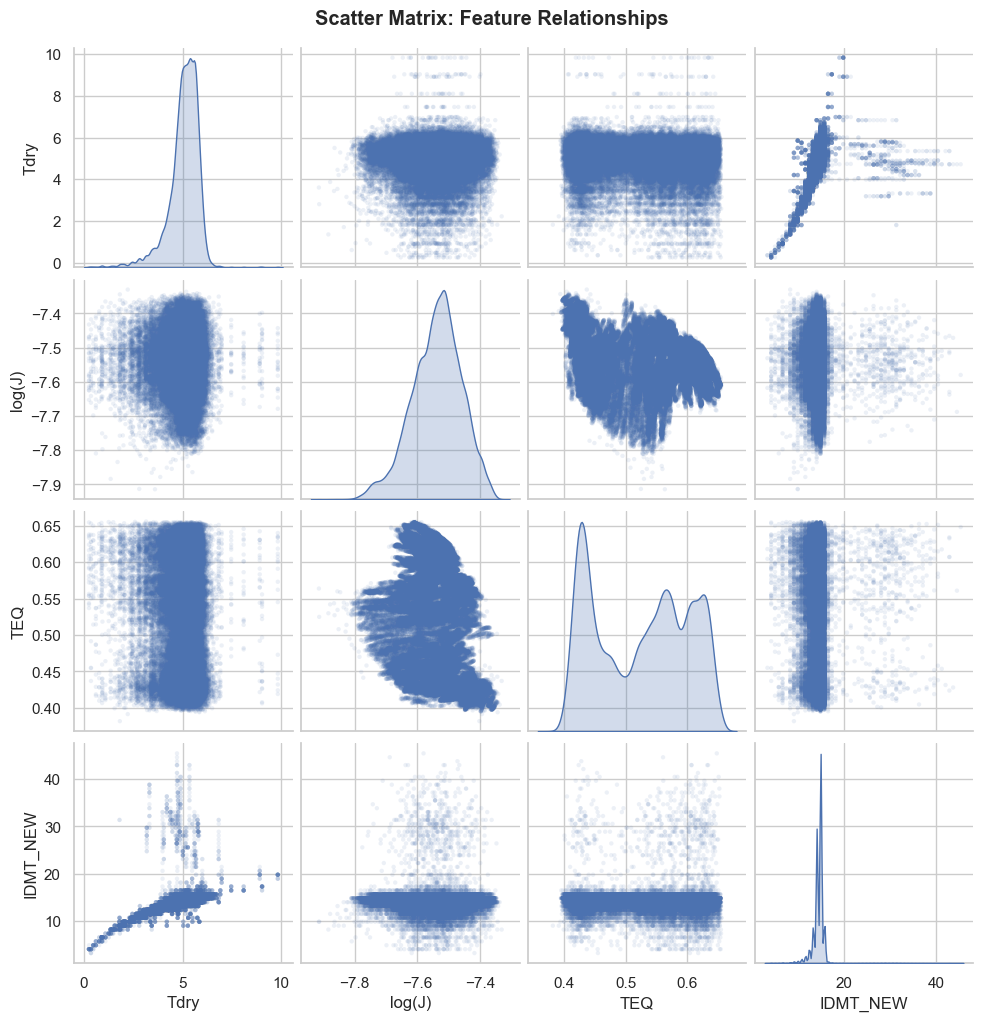

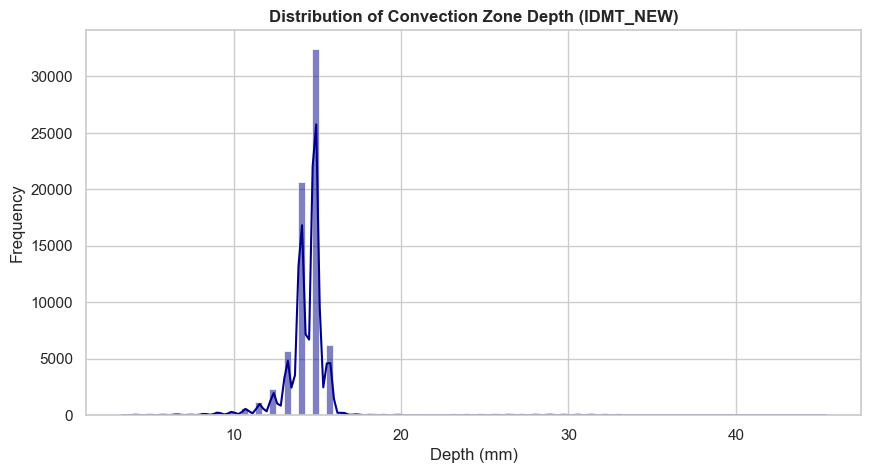

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data exactly like we did for PySR
file_name = "S5 Twd J TEQ IDMT log(j).xlsx" 
print(f"Loading {file_name} for Analysis...")
df_all = pd.read_excel(file_name)

# Isolate Level 5
df_target = df_all[df_all['Level'] == 5].copy()

# Select our core features and target
features = ['Twet', 'Tdry', 'J', 'log(J)', 'TEQ', 'IDMT_NEW']
df_clean = df_target[features].dropna()

print(f"Analyzing {len(df_clean)} rows of clean data...")

# Set up the visual style
sns.set_theme(style="whitegrid")

# --- PLOT 1: Correlation Heatmap ---
plt.figure(figsize=(8, 6))
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation with IDMT_NEW (Level 5)", fontweight='bold')
plt.show()

# --- PLOT 2: Scatter Plots (Pairplot) ---
# We only plot a subset to keep it readable
plot_vars = ['Tdry', 'log(J)', 'TEQ', 'IDMT_NEW']
sns.pairplot(df_clean[plot_vars], kind='scatter', diag_kind='kde', 
             plot_kws={'alpha':0.1, 's':10, 'edgecolor':'none'}) # Alpha=0.1 helps visualize dense 71k clusters
plt.suptitle("Scatter Matrix: Feature Relationships", y=1.02, fontweight='bold')
plt.show()

# --- PLOT 3: Target Distribution ---
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['IDMT_NEW'], bins=100, color='darkblue', kde=True)
plt.title("Distribution of Convection Zone Depth (IDMT_NEW)", fontweight='bold')
plt.xlabel("Depth (mm)")
plt.ylabel("Frequency")
plt.show()

In [1]:
# import os
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.metrics import r2_score
# from pysr import PySRRegressor

# def SimplePysr(df, target_level):
#     features = ['Tdry','Twet',  'J', 'TEQ']
#     target = 'IDMT_NEW' 
    
#     df_clean = df[features + [target]].dropna()
    
#     if df_clean.empty:
#         print(f"Skipping Level {target_level}: DataFrame is empty after dropping NaNs.")
#         return None, None, "DataFrame empty"
        
#     X = df_clean[features].values
#     y = df_clean[target].values
    
#     if X.shape[0] < 2:
#         print(f"Skipping Level {target_level}: Not enough data.")
#         return None, None, "Not enough data"
        
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
#     scaler = MinMaxScaler() 
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)
    
#     temp_dir_for_run = f"pysr_temp_2/run_Level_{target_level}/"
#     os.makedirs(temp_dir_for_run, exist_ok=True)

#     model = PySRRegressor(
#         niterations=100, 
#         population_size=80,
#         procs=1,               
#         multithreading=False, 
#         loss="L1DistLoss()",
#         model_selection="best",
#         maxsize=25,
#         unary_operators=["sqrt", "log1p", "exp", "abs"],
#         binary_operators=["+", "-", "*", "div", "pow"],
#         progress=True, 
#         random_state=42,
#         tempdir=temp_dir_for_run,  
#         delete_tempfiles=False,
#         variable_names=features 
#     )
    
#     print(f"Fitting PySR for Level {target_level}...")
#     model.fit(X_train_scaled, y_train)

#     if not model.get_best().empty:
#         eq = model.get_best()['equation']
#         print(f"  Best equation: {eq}")

#         y_pred_train = model.predict(X_train_scaled)
#         train_finite_idx = np.isfinite(y_pred_train)
#         y_train_filtered = y_train[train_finite_idx]
#         y_pred_train_filtered = y_pred_train[train_finite_idx]

#         if y_train_filtered.size > 0:
#             train_r2 = r2_score(y_train_filtered, y_pred_train_filtered)
#         else:
#             print("  Warning: All training predictions were NaN/Inf.")
#             train_r2 = np.nan

#         y_pred_test = model.predict(X_test_scaled)
#         test_finite_idx = np.isfinite(y_pred_test)
#         y_test_filtered = y_test[test_finite_idx]
#         y_pred_test_filtered = y_pred_test[test_finite_idx]

#         if y_test_filtered.size > 0:
#             test_r2 = r2_score(y_test_filtered, y_pred_test_filtered)
#             print(f"  Test R2: {test_r2:.4f}")
#         else:
#             print("  Warning: All test predictions were NaN/Inf.")
#             test_r2 = np.nan
        
#         return train_r2, test_r2, eq
#     else:
#         print("  No equation found.")
#         return None, None, "No equation found"

# file_name = "New Data S1 L5.xlsx" 

# print(f"Loading dataset from: {file_name}...")
# df_all = pd.read_excel(file_name) 

# target_level = 5

# # Removed the 'Station' filter completely since it's not in your sheet!
# df_target = df_all[df_all['Level'] == target_level].copy()

# if df_target.empty:
#     print(f"\nError: Could not find any rows for Level {target_level}.")
# else:
#     print(f"Successfully extracted {len(df_target)} rows for Level {target_level}.")
    
#     # Run PySR
#     train_r2, test_r2, best_eq = SimplePysr(df_target, target_level)

#     if best_eq:
#         print("\n--- FINAL RESULTS ---")
#         print(f"Equation: {best_eq}")
#         print(f"Train R2: {train_r2:.4f}")
#         print(f"Test R2:  {test_r2:.4f}")

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from pysr import PySRRegressor

def SimplePysr(df, target_level):

    # -----------------------------
    # 🔥 1. FEATURE ENGINEERING (NEW)
    # -----------------------------
    df = df.copy()

    df["sqrt_Tdry"] = np.sqrt(df["Tdry"])
    df["sqrt_Twet"] = np.sqrt(df["Twet"])
    df["ratio_T"] = df["Tdry"] / (df["Twet"] + 1e-6)

    df["log_J"] = np.log1p(df["J"])
    df["inv_TEQ"] = 1 / (df["TEQ"] + 1e-6)
    df["J_over_TEQ"] = df["J"] / (df["TEQ"] + 1e-6)

    # -----------------------------
    # 🔥 2. UPDATED FEATURES
    # -----------------------------
    # features = [
    #     'Tdry', 'Twet',
    #     'sqrt_Tdry', 'sqrt_Twet',
    #     'ratio_T',
    #     'J', 'TEQ',
    #     'log_J', 'inv_TEQ', 'J_over_TEQ'
    # ]

    features = ['ratio_T', 'sqrt_Tdry']
    target = 'IDMT_NEW'

    df_clean = df[features + [target]].dropna()

    if df_clean.empty:
        print(f"Skipping Level {target_level}: DataFrame is empty.")
        return None, None, "DataFrame empty"

    X = df_clean[features].values
    y = df_clean[target].values

    if X.shape[0] < 2:
        print(f"Skipping Level {target_level}: Not enough data.")
        return None, None, "Not enough data"

    # -----------------------------
    # Train-Test Split
    # -----------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # -----------------------------
    # Scaling
    # -----------------------------
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    temp_dir_for_run = f"pysr_temp_2/run_Level_{target_level}/"
    os.makedirs(temp_dir_for_run, exist_ok=True)

    # -----------------------------
    # 🔥 3. IMPROVED PySR MODEL
    # -----------------------------
    model = PySRRegressor(
        niterations=100,                # 🔥 more search
        population_size=100,

        procs=1,
        multithreading=False,

        loss="L1DistLoss()",
        model_selection="best",

        maxsize=20,                    # 🔥 simpler equations
        parsimony=0.01,                # 🔥 penalize complexity

        # ✅ SAFE OPERATORS ONLY
        unary_operators=[
            "sqrt",
            "log1p",
            "abs"
        ],

        binary_operators=[
            "+",
            "-",
            "*",
            "div"
        ],

        progress=True,
        random_state=42,

        tempdir=temp_dir_for_run,
        delete_tempfiles=False,

        variable_names=features
    )

    print(f"Fitting PySR for Level {target_level}...")
    model.fit(X_train_scaled, y_train)

    # -----------------------------
    # RESULTS
    # -----------------------------
    if not model.get_best().empty:
        eq = model.get_best()['equation']
        print(f"\nBest equation: {eq}")

        # Train prediction
        y_pred_train = model.predict(X_train_scaled)
        train_mask = np.isfinite(y_pred_train)

        if np.sum(train_mask) > 0:
            train_r2 = r2_score(y_train[train_mask], y_pred_train[train_mask])
        else:
            train_r2 = np.nan

        # Test prediction
        y_pred_test = model.predict(X_test_scaled)
        test_mask = np.isfinite(y_pred_test)

        if np.sum(test_mask) > 0:
            test_r2 = r2_score(y_test[test_mask], y_pred_test[test_mask])
            print(f"Test R2: {test_r2:.4f}")
        else:
            test_r2 = np.nan

        return train_r2, test_r2, eq

    else:
        print("No equation found.")
        return None, None, "No equation found"


# -----------------------------
# MAIN
# -----------------------------
file_name = "S1 L5 with 0.01.xlsx"

print(f"Loading dataset from: {file_name}...")
df_all = pd.read_excel(file_name)

target_level = 5

df_target = df_all[df_all['Level'] == target_level].copy()

if df_target.empty:
    print(f"\nError: Could not find any rows for Level {target_level}.")
else:
    print(f"Successfully extracted {len(df_target)} rows.")

    train_r2, test_r2, best_eq = SimplePysr(df_target, target_level)

    if best_eq:
        print("\n--- FINAL RESULTS ---")
        print(f"Equation: {best_eq}")
        print(f"Train R2: {train_r2:.4f}")
        print(f"Test R2:  {test_r2:.4f}")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Loading dataset from: S1 L5 with 0.01.xlsx...
Successfully extracted 71017 rows.
Fitting PySR for Level 5...
Compiling Julia backend...


d:\MTP\Code\MTP\Lib\site-packages\pysr\sr.py:915: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
d:\MTP\Code\MTP\Lib\site-packages\pysr\sr.py:922: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
d:\MTP\Code\MTP\Lib\site-packages\pysr\sr.py:1310: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
d:\MTP\Code\MTP\Lib\site-packages\pysr\sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
d:\MTP\Code\MTP\Lib\site-packages\pysr\sr.py:2029: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://astroautomata.com/PySR/opti


Expressions evaluated per second: 0.000e+00
Head worker occupation: 0.0%
Progress: 0 / 1500 total iterations (0.000%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 0.000e+00
Head worker occupation: 0.0%
Progress: 1 / 1500 total iterations (0.067%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           6.957e+00  7.971e+00  y = abs(-2.2161)
4           6.299e+00  4.974e-02  y = abs(-2.2161 - x₁)
5           6.148e+00  2.426e-02  y = abs(sqrt(x₁) - -2.2161)
6           4.573e+00  2.960e-01  y = (0.76381 - -0.42214) + abs(-3.4267)
8           4.046e+00  6.120e-02  y = (x₁ - (x₀ - 1.192

In [ ]:
# import os
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.metrics import r2_score
# from pysr import PySRRegressor

# def SimplePysr(df, target_level):
#     features = ['Tdry','Twet',  'J', 'TEQ']
#     target = 'IDMT_NEW' 
    
#     df_clean = df[features + [target]].dropna()
    
#     if df_clean.empty:
#         print(f"Skipping Level {target_level}: DataFrame is empty after dropping NaNs.")
#         return None, None, "DataFrame empty"
        
#     X = df_clean[features].values
#     y = df_clean[target].values
    
#     if X.shape[0] < 2:
#         print(f"Skipping Level {target_level}: Not enough data.")
#         return None, None, "Not enough data"
        
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
#     scaler = MinMaxScaler() 
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)
    
#     temp_dir_for_run = f"pysr_temp_2/run_Level_{target_level}/"
#     os.makedirs(temp_dir_for_run, exist_ok=True)

#     model = PySRRegressor(
#         niterations=100, 
#         population_size=80,
#         procs=1,               
#         multithreading=False, 
#         loss="L1DistLoss()",
#         model_selection="best",
#         maxsize=25,
#         unary_operators=["sqrt", "log1p", "exp", "abs"],
#         binary_operators=["+", "-", "*", "div", "pow"],
#         progress=True, 
#         random_state=42,
#         tempdir=temp_dir_for_run,  
#         delete_tempfiles=False,
#         variable_names=features 
#     )
    
#     print(f"Fitting PySR for Level {target_level}...")
#     model.fit(X_train_scaled, y_train)

#     if not model.get_best().empty:
#         eq = model.get_best()['equation']
#         print(f"  Best equation: {eq}")

#         y_pred_train = model.predict(X_train_scaled)
#         train_finite_idx = np.isfinite(y_pred_train)
#         y_train_filtered = y_train[train_finite_idx]
#         y_pred_train_filtered = y_pred_train[train_finite_idx]

#         if y_train_filtered.size > 0:
#             train_r2 = r2_score(y_train_filtered, y_pred_train_filtered)
#         else:
#             print("  Warning: All training predictions were NaN/Inf.")
#             train_r2 = np.nan

#         y_pred_test = model.predict(X_test_scaled)
#         test_finite_idx = np.isfinite(y_pred_test)
#         y_test_filtered = y_test[test_finite_idx]
#         y_pred_test_filtered = y_pred_test[test_finite_idx]

#         if y_test_filtered.size > 0:
#             test_r2 = r2_score(y_test_filtered, y_pred_test_filtered)
#             print(f"  Test R2: {test_r2:.4f}")
#         else:
#             print("  Warning: All test predictions were NaN/Inf.")
#             test_r2 = np.nan
        
#         return train_r2, test_r2, eq
#     else:
#         print("  No equation found.")
#         return None, None, "No equation found"

# file_name = "New Data S1 L5.xlsx" 

# print(f"Loading dataset from: {file_name}...")
# df_all = pd.read_excel(file_name) 

# target_level = 5

# # Removed the 'Station' filter completely since it's not in your sheet!
# df_target = df_all[df_all['Level'] == target_level].copy()

# if df_target.empty:
#     print(f"\nError: Could not find any rows for Level {target_level}.")
# else:
#     print(f"Successfully extracted {len(df_target)} rows for Level {target_level}.")
    
#     # Run PySR
#     train_r2, test_r2, best_eq = SimplePysr(df_target, target_level)

#     if best_eq:
#         print("\n--- FINAL RESULTS ---")
#         print(f"Equation: {best_eq}")
#         print(f"Train R2: {train_r2:.4f}")
#         print(f"Test R2:  {test_r2:.4f}")

# import os
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.metrics import r2_score
# from pysr import PySRRegressor

# def SimplePysr(df, target_level):
#     features = ['Tdry','Twet',  'J', 'TEQ']
#     target = 'IDMT_NEW' 
    
#     df_clean = df[features + [target]].dropna()
    
#     if df_clean.empty:
#         print(f"Skipping Level {target_level}: DataFrame is empty after dropping NaNs.")
#         return None, None, "DataFrame empty"
        
#     X = df_clean[features].values
#     y = df_clean[target].values
    
#     if X.shape[0] < 2:
#         print(f"Skipping Level {target_level}: Not enough data.")
#         return None, None, "Not enough data"
        
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
#     scaler = MinMaxScaler() 
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)
    
#     temp_dir_for_run = f"pysr_temp_2/run_Level_{target_level}/"
#     os.makedirs(temp_dir_for_run, exist_ok=True)

#     model = PySRRegressor(
#         niterations=100, 
#         population_size=80,
#         procs=1,               
#         multithreading=False, 
#         loss="L1DistLoss()",
#         model_selection="best",
#         maxsize=25,
#         unary_operators=["sqrt", "log1p", "exp", "abs"],
#         binary_operators=["+", "-", "*", "div", "pow"],
#         progress=True, 
#         random_state=42,
#         tempdir=temp_dir_for_run,  
#         delete_tempfiles=False,
#         variable_names=features 
#     )
    
#     print(f"Fitting PySR for Level {target_level}...")
#     model.fit(X_train_scaled, y_train)

#     if not model.get_best().empty:
#         eq = model.get_best()['equation']
#         print(f"  Best equation: {eq}")

#         y_pred_train = model.predict(X_train_scaled)
#         train_finite_idx = np.isfinite(y_pred_train)
#         y_train_filtered = y_train[train_finite_idx]
#         y_pred_train_filtered = y_pred_train[train_finite_idx]

#         if y_train_filtered.size > 0:
#             train_r2 = r2_score(y_train_filtered, y_pred_train_filtered)
#         else:
#             print("  Warning: All training predictions were NaN/Inf.")
#             train_r2 = np.nan

#         y_pred_test = model.predict(X_test_scaled)
#         test_finite_idx = np.isfinite(y_pred_test)
#         y_test_filtered = y_test[test_finite_idx]
#         y_pred_test_filtered = y_pred_test[test_finite_idx]

#         if y_test_filtered.size > 0:
#             test_r2 = r2_score(y_test_filtered, y_pred_test_filtered)
#             print(f"  Test R2: {test_r2:.4f}")
#         else:
#             print("  Warning: All test predictions were NaN/Inf.")
#             test_r2 = np.nan
        
#         return train_r2, test_r2, eq
#     else:
#         print("  No equation found.")
#         return None, None, "No equation found"

# file_name = "New Data S1 L5.xlsx" 

# print(f"Loading dataset from: {file_name}...")
# df_all = pd.read_excel(file_name) 

# target_level = 5

# # Removed the 'Station' filter completely since it's not in your sheet!
# df_target = df_all[df_all['Level'] == target_level].copy()

# if df_target.empty:
#     print(f"\nError: Could not find any rows for Level {target_level}.")
# else:
#     print(f"Successfully extracted {len(df_target)} rows for Level {target_level}.")
    
#     # Run PySR
#     train_r2, test_r2, best_eq = SimplePysr(df_target, target_level)

#     if best_eq:
#         print("\n--- FINAL RESULTS ---")
#         print(f"Equation: {best_eq}")
#         print(f"Train R2: {train_r2:.4f}")
#         print(f"Test R2:  {test_r2:.4f}")

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from pysr import PySRRegressor

def SimplePysr(df, target_level):

    # -----------------------------
    # 🔥 1. FEATURE ENGINEERING (NEW)
    # -----------------------------
    df = df.copy()

    df["sqrt_Tdry"] = np.sqrt(df["Tdry"])
    df["sqrt_Twet"] = np.sqrt(df["Twet"])
    df["ratio_T"] = df["Tdry"] / (df["Twet"] + 1e-6)

    df["log_J"] = np.log1p(df["J"])
    df["inv_TEQ"] = 1 / (df["TEQ"] + 1e-6)
    df["J_over_TEQ"] = df["J"] / (df["TEQ"] + 1e-6)

    # -----------------------------
    # 🔥 2. UPDATED FEATURES
    # -----------------------------
    # features = [
    #     'Tdry', 'Twet',
    #     'sqrt_Tdry', 'sqrt_Twet',
    #     'ratio_T',
    #     'J', 'TEQ',
    #     'log_J', 'inv_TEQ', 'J_over_TEQ'
    # ]

    features = [ 'sqrt_Tdry', 'J_over_TEQ']
    target = 'IDMT_NEW'

    df_clean = df[features + [target]].dropna()

    if df_clean.empty:
        print(f"Skipping Level {target_level}: DataFrame is empty.")
        return None, None, "DataFrame empty"

    X = df_clean[features].values
    y = df_clean[target].values

    if X.shape[0] < 2:
        print(f"Skipping Level {target_level}: Not enough data.")
        return None, None, "Not enough data"

    # -----------------------------
    # Train-Test Split
    # -----------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # -----------------------------
    # Scaling
    # -----------------------------
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    temp_dir_for_run = f"pysr_temp_2/run_Level_{target_level}/"
    os.makedirs(temp_dir_for_run, exist_ok=True)

    # -----------------------------
    # 🔥 3. IMPROVED PySR MODEL
    # -----------------------------
    model = PySRRegressor(
        niterations=100,                # 🔥 more search
        population_size=100,

        procs=1,
        multithreading=False,

        loss="L1DistLoss()",
        model_selection="best",

        maxsize=20,                    # 🔥 simpler equations
        parsimony=0.01,                # 🔥 penalize complexity

        # ✅ SAFE OPERATORS ONLY
        unary_operators=[
            "sqrt",
            "log1p",
            "abs"
        ],

        binary_operators=[
            "+",
            "-",
            "*",
            "div"
        ],

        progress=True,
        random_state=42,

        tempdir=temp_dir_for_run,
        delete_tempfiles=False,

        variable_names=features
    )

    print(f"Fitting PySR for Level {target_level}...")
    model.fit(X_train_scaled, y_train)

    # -----------------------------
    # RESULTS
    # -----------------------------
    if not model.get_best().empty:
        eq = model.get_best()['equation']
        print(f"\nBest equation: {eq}")

        # Train prediction
        y_pred_train = model.predict(X_train_scaled)
        train_mask = np.isfinite(y_pred_train)

        if np.sum(train_mask) > 0:
            train_r2 = r2_score(y_train[train_mask], y_pred_train[train_mask])
        else:
            train_r2 = np.nan

        # Test prediction
        y_pred_test = model.predict(X_test_scaled)
        test_mask = np.isfinite(y_pred_test)

        if np.sum(test_mask) > 0:
            test_r2 = r2_score(y_test[test_mask], y_pred_test[test_mask])
            print(f"Test R2: {test_r2:.4f}")
        else:
            test_r2 = np.nan

        return train_r2, test_r2, eq

    else:
        print("No equation found.")
        return None, None, "No equation found"


# -----------------------------
# MAIN
# -----------------------------
file_name = "S1 L5 with 0.01.xlsx"

print(f"Loading dataset from: {file_name}...")
df_all = pd.read_excel(file_name)

target_level = 5

df_target = df_all[df_all['Level'] == target_level].copy()

if df_target.empty:
    print(f"\nError: Could not find any rows for Level {target_level}.")
else:
    print(f"Successfully extracted {len(df_target)} rows.")

    train_r2, test_r2, best_eq = SimplePysr(df_target, target_level)

    if best_eq:
        print("\n--- FINAL RESULTS ---")
        print(f"Equation: {best_eq}")
        print(f"Train R2: {train_r2:.4f}")
        print(f"Test R2:  {test_r2:.4f}")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Loading dataset from: S1 L5 with 0.01.xlsx...
Successfully extracted 71017 rows.
Fitting PySR for Level 5...
Compiling Julia backend...


d:\MTP\Code\MTP\Lib\site-packages\pysr\sr.py:915: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
d:\MTP\Code\MTP\Lib\site-packages\pysr\sr.py:922: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
d:\MTP\Code\MTP\Lib\site-packages\pysr\sr.py:1310: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
d:\MTP\Code\MTP\Lib\site-packages\pysr\sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
d:\MTP\Code\MTP\Lib\site-packages\pysr\sr.py:2029: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://astroautomata.com/PySR/opti


Expressions evaluated per second: 0.000e+00
Head worker occupation: 0.0%
Progress: 0 / 1500 total iterations (0.000%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 0.000e+00
Head worker occupation: 0.0%
Progress: 0 / 1500 total iterations (0.000%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 0.000e+00
Head worker occupation: 0.0%
Progress: 0 / 1500 total iterations (0.000%)
Hall of Fame:
-------------